# FNN网络拟合一元函数

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='0'
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

import time
import scipy.io as io
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

torch.manual_seed(1234)
np.random.seed(1234)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('running on: %s'%(device))


running on: cuda


## 构建FNN网络

In [2]:
## ----构建FNN网络----
class FNN(nn.Module):
    def __init__(self, layers, actn = 'tanh'):
        super().__init__()
        L = len(layers)


        self.linear = nn.ModuleList([nn.Linear(layers[l-1], layers[l]) for l in range(1, L)])

        # 激活函数
        if actn == 'relu':
            actn = nn.ReLU()
        elif actn == 'tanh':
            actn = nn.Tanh()
        elif actn == 'sigmoid':
            actn = nn.Sigmoid()
        self.activation = actn

    def forward(self, inputs):
        x = inputs
        for linear in self.linear[:-1]:
            x = self.activation(linear(x))
        x = self.linear[-1](x)
        return x


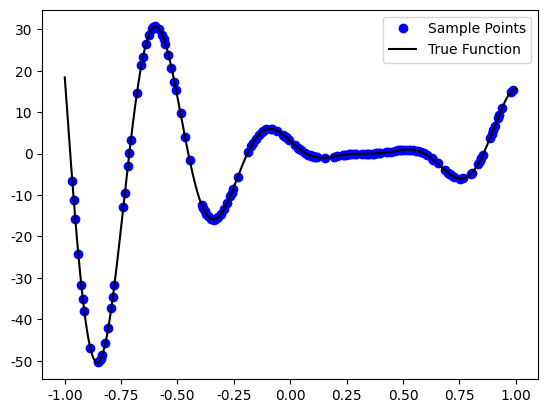

In [3]:


# 目标函数
def target_func(x):
    return (6*x-2)**2 * np.sin(12*x-4)

# 生成数据
def generate_data(num_train=150): # 样本点数
    num_test = 301 # 全集与样本点数
    x = np.linspace(-1, 1, num_test).reshape((-1, 1))
    y = target_func(x)
    idx = np.random.choice(num_test, num_train,  replace=False)

    #训练点数
    x_train, y_train = x[idx], y[idx]
    return x_train, y_train, x, y

# 训练点数
num_train = 150
# 数据集
x_train, y_train, x_ref, y_ref = generate_data(num_train)

plt.figure()
matplotlib.rcParams['axes.unicode_minus'] =False
# plt.rcParams['font.sans-serif']=['KaiTi'] 
plt.plot(x_train, y_train, 'bo',label='Sample Points')
plt.plot(x_ref, y_ref, 'k-',label='True Function')
plt.legend()
plt.show()

## 模型训练

In [4]:
## ----模型训练---

# 训练模型
def train_model(x_train, y_train, layers=[1, 50, 50, 1], actn='tanh', epochs=10000):
    # 网络模型
    model = FNN(layers, actn)
    model = model.to(device)
    print(model.state_dict()['linear.2.weight'].shape)

    x_train, y_train = torch.tensor(x_train, dtype=torch.float32), \
        torch.tensor(y_train, dtype=torch.float32)
    x_train, y_train = x_train.to(device), y_train.to(device)


    opt = torch.optim.Adam(model.parameters(), lr=1.0e-3)
    loss_fn = nn.MSELoss()

    loss_history = []

    for epoch in range(1,epochs+1):
        y_pred = model(x_train)
        loss = loss_fn(y_pred, y_train)

        opt.zero_grad() #梯度清零
        loss.backward()
        opt.step()
        loss_history.append(loss.item())


        if epoch%1000 == 0:
            print('Steps: %d, loss: %.3e'%(epoch, loss.item()))
    loss_history = np.array(loss_history).reshape(-1,1)
    return model.cpu(),loss_history

#  网络结构层数与深度
layers = [1] + [100]*3 + [1]
# 激活函数
actn = 'tanh'
# 训练轮次
epochs = 5000


model, loss = train_model(x_train, y_train, layers, actn, epochs)



torch.Size([100, 100])
Steps: 1000, loss: 9.184e+01
Steps: 2000, loss: 9.122e+01
Steps: 3000, loss: 9.111e+01
Steps: 4000, loss: 9.102e+01
Steps: 5000, loss: 9.096e+01


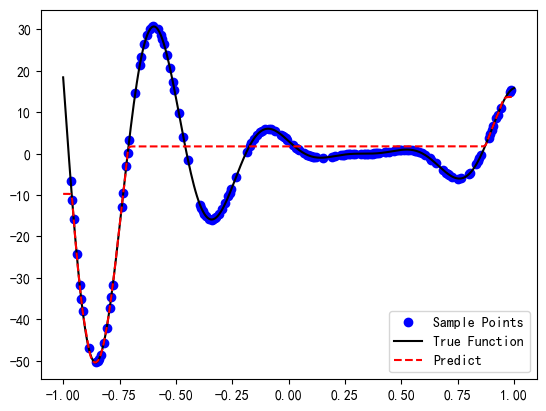

In [5]:
x_ref = torch.tensor(x_ref, dtype=torch.float32)
y_test = model(x_ref)

plt.figure()
plt.rcParams['font.sans-serif']=['KaiTi'] 
plt.plot(x_train, y_train, 'bo',label='Sample Points')
plt.plot(x_ref, y_ref, 'k-',label='True Function')

plt.plot(x_ref, y_test.detach().numpy(), 'r--',label="Predict")
plt.legend()
plt.show()

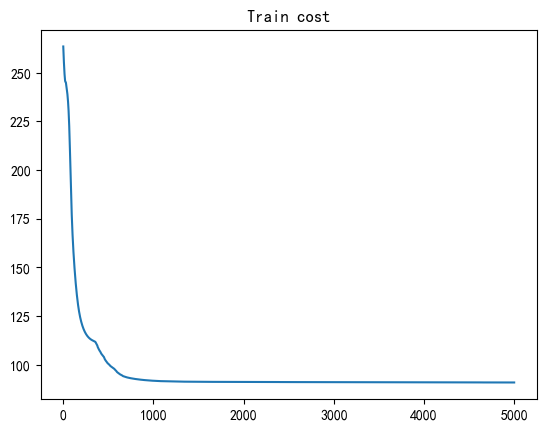

In [6]:
nsum = np.array([i+1 for i in range(epochs)]).reshape(-1,1)

plt.figure()
plt.plot(nsum, loss ,label="Train cost")
plt.title('Train cost')
plt.show()

In [7]:
## 模型评估

def evaluate(model):

    x_test=np.linspace(-1,1,301).reshape((-1,1))
    y_true=target_func(x_test)

    x_test_tensor=torch.tensor(x_test, dtype=torch.float32)

    with torch.no_grad():
        y_pred=model.cpu()(x_test_tensor)

    mse=mean_squared_error(y_true,y_pred)
    mae=mean_absolute_error(y_true,y_pred)

    return x_test, y_true, y_pred, mse, mae
 
test = evaluate(model)
print(dict(zip(['MSE','MAE'],test[3:])))

{'MSE': 85.4429309235453, 'MAE': 5.633810450762722}


In [8]:
def plot_result(x_true,y_true,y_pred,title):
    plt.figure(figsize=(6,4))
    plt.plot(x_true,y_true,label="True Function")
    plt.plot(x_true,y_pred,label="Prediction")
    plt.legend()
    plt.title(title)
    plt.show()


def plot_loss(loss_dict, title):
    plt.figure()
    for key, loss in loss_dict.items():
        plt.plot(loss, label=key)

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.show()


## 问题1：训练点数影响

torch.Size([1, 50])
Steps: 1000, loss: 1.722e+01
Steps: 2000, loss: 3.079e+00
Steps: 3000, loss: 2.417e+00
Steps: 4000, loss: 2.406e+00
Steps: 5000, loss: 1.165e+00
Steps: 6000, loss: 1.097e+00
Steps: 7000, loss: 1.087e+00
Steps: 8000, loss: 1.017e-01
Steps: 9000, loss: 3.194e-07
Steps: 10000, loss: 4.813e-05


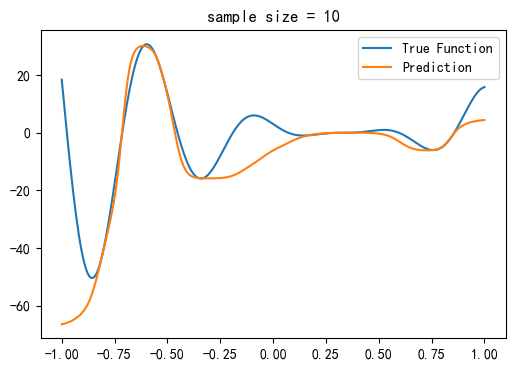

torch.Size([1, 50])
Steps: 1000, loss: 9.254e+00
Steps: 2000, loss: 6.474e+00
Steps: 3000, loss: 5.859e+00
Steps: 4000, loss: 5.704e+00
Steps: 5000, loss: 5.685e+00
Steps: 6000, loss: 5.680e+00
Steps: 7000, loss: 5.677e+00
Steps: 8000, loss: 5.676e+00
Steps: 9000, loss: 5.675e+00
Steps: 10000, loss: 5.675e+00


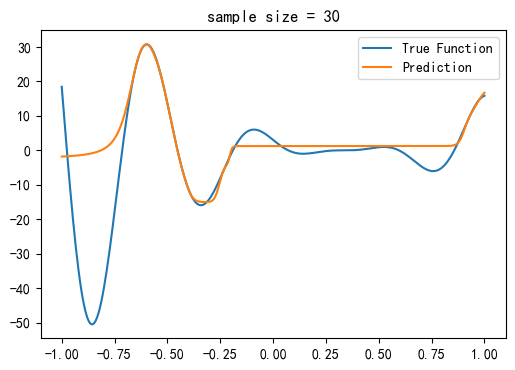

torch.Size([1, 50])
Steps: 1000, loss: 3.405e+01
Steps: 2000, loss: 1.140e+01
Steps: 3000, loss: 8.996e+00
Steps: 4000, loss: 5.981e+00
Steps: 5000, loss: 5.643e+00
Steps: 6000, loss: 5.621e+00
Steps: 7000, loss: 5.613e+00
Steps: 8000, loss: 5.610e+00
Steps: 9000, loss: 2.609e+00
Steps: 10000, loss: 1.625e+00


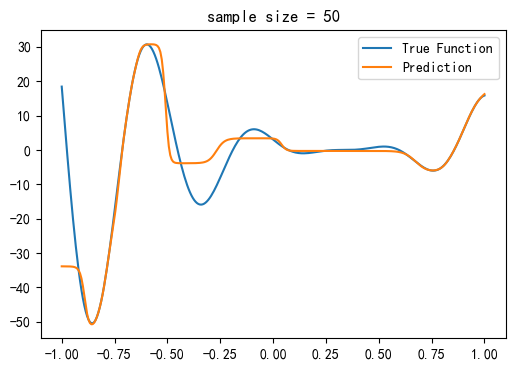

torch.Size([1, 50])
Steps: 1000, loss: 4.795e+01
Steps: 2000, loss: 2.915e+01
Steps: 3000, loss: 2.663e+01
Steps: 4000, loss: 2.518e+01
Steps: 5000, loss: 2.406e+01
Steps: 6000, loss: 2.297e+01
Steps: 7000, loss: 2.200e+01
Steps: 8000, loss: 2.123e+01
Steps: 9000, loss: 2.062e+01
Steps: 10000, loss: 2.014e+01


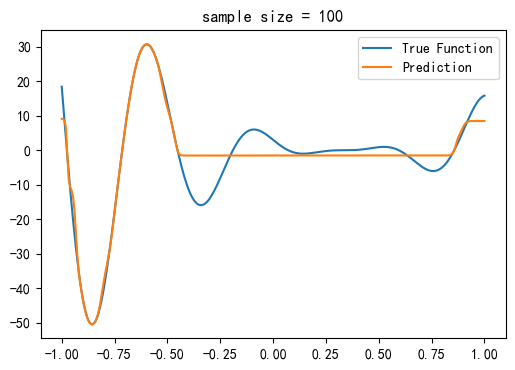

torch.Size([1, 50])
Steps: 1000, loss: 8.640e+01
Steps: 2000, loss: 5.875e+01
Steps: 3000, loss: 5.070e+01
Steps: 4000, loss: 4.419e+01
Steps: 5000, loss: 3.916e+01
Steps: 6000, loss: 3.501e+01
Steps: 7000, loss: 3.154e+01
Steps: 8000, loss: 2.867e+01
Steps: 9000, loss: 2.630e+01
Steps: 10000, loss: 2.437e+01


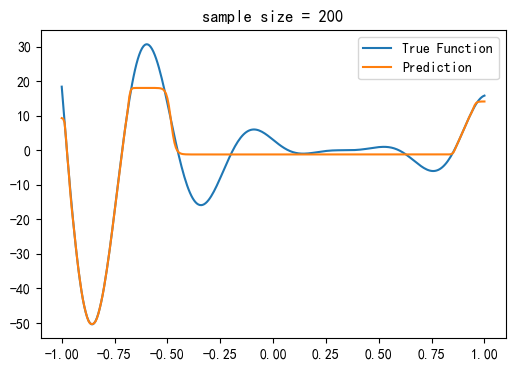

[[ 10.         188.75641637   6.35730475]
 [ 30.         171.44818188   5.86957958]
 [ 50.          50.79956654   2.91775845]
 [100.          20.10707671   2.92490459]
 [200.          25.14678615   3.19032371]]


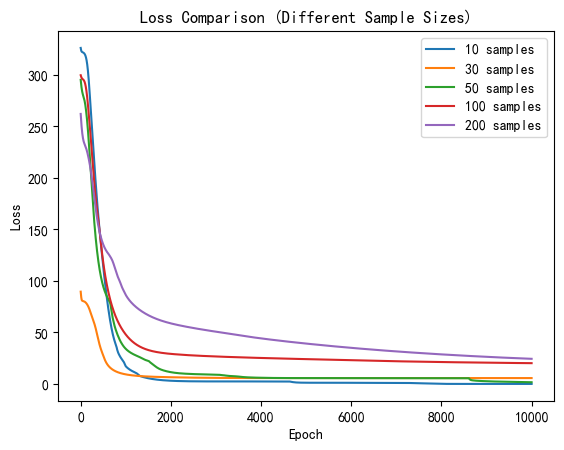

In [9]:
## ----训练点数影响----
sample_sizes = [10, 30, 50, 100, 200]

results_q1 = []
loss_dict_q1 = {}

for n in sample_sizes:
    x_train_q1, y_train_q1, x_ref_q1, y_ref_q1 = generate_data(n)
    model_q1 ,loss_q1= train_model(x_train_q1, y_train_q1)

    x_test_q1, y_true_q1, y_pred_q1, mse_q1, mae_q1 = evaluate(model_q1)
    results_q1.append([n, mse_q1, mae_q1])

    loss_dict_q1[str(n)+' samples']=loss_q1
    
    plot_result(x_test_q1, y_true_q1, y_pred_q1,f"sample size = {n}")
print(np.array(results_q1))

plot_loss(loss_dict_q1, title='Loss Comparison (Different Sample Sizes)')

## 问题2：网络结构（层数与深度）影响

[1, 20, 20, 1]
torch.Size([1, 20])
Steps: 1000, loss: 1.475e+02
Steps: 2000, loss: 1.130e+02
Steps: 3000, loss: 1.006e+02
Steps: 4000, loss: 9.492e+01
Steps: 5000, loss: 9.097e+01
Steps: 6000, loss: 8.818e+01
Steps: 7000, loss: 8.613e+01
Steps: 8000, loss: 8.457e+01
Steps: 9000, loss: 8.344e+01
Steps: 10000, loss: 8.265e+01
structure: [20, 20] MSE: 82.32329162164059 MAE: 5.542842255156566


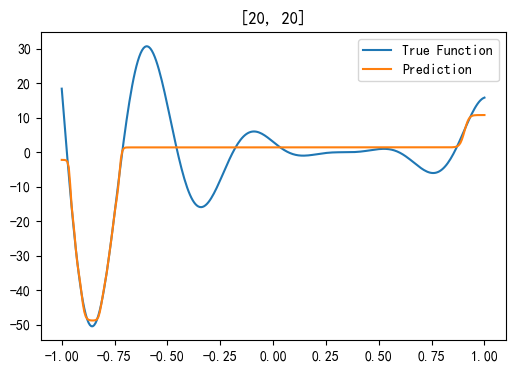

[1, 20, 20, 20, 1]
torch.Size([20, 20])
Steps: 1000, loss: 9.305e+01
Steps: 2000, loss: 7.252e+01
Steps: 3000, loss: 7.149e+01
Steps: 4000, loss: 7.136e+01
Steps: 5000, loss: 7.131e+01
Steps: 6000, loss: 4.391e+01
Steps: 7000, loss: 1.560e+01
Steps: 8000, loss: 1.451e+01
Steps: 9000, loss: 1.437e+01
Steps: 10000, loss: 1.434e+01
structure: [20, 20, 20] MSE: 17.26139535311986 MAE: 2.100842200530336


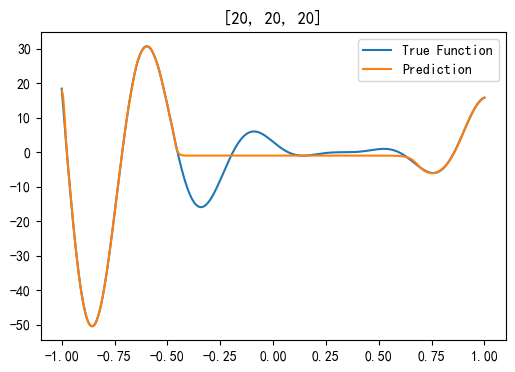

[1, 50, 50, 1]
torch.Size([1, 50])
Steps: 1000, loss: 7.407e+01
Steps: 2000, loss: 5.630e+01
Steps: 3000, loss: 4.984e+01
Steps: 4000, loss: 4.650e+01
Steps: 5000, loss: 4.405e+01
Steps: 6000, loss: 4.189e+01
Steps: 7000, loss: 3.827e+01
Steps: 8000, loss: 3.372e+01
Steps: 9000, loss: 3.075e+01
Steps: 10000, loss: 2.829e+01
structure: [50, 50] MSE: 28.488497193443727 MAE: 3.4100524505719405


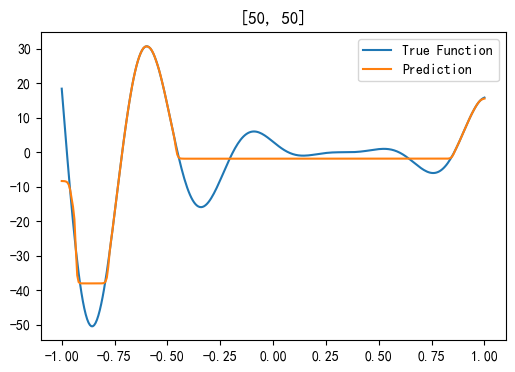

[1, 50, 50, 50, 1]
torch.Size([50, 50])
Steps: 1000, loss: 8.908e+01
Steps: 2000, loss: 7.965e+01
Steps: 3000, loss: 7.641e+01
Steps: 4000, loss: 7.475e+01
Steps: 5000, loss: 7.368e+01
Steps: 6000, loss: 7.286e+01
Steps: 7000, loss: 7.220e+01
Steps: 8000, loss: 7.165e+01
Steps: 9000, loss: 7.120e+01
Steps: 10000, loss: 7.080e+01
structure: [50, 50, 50] MSE: 80.46556117596623 MAE: 5.626617614073188


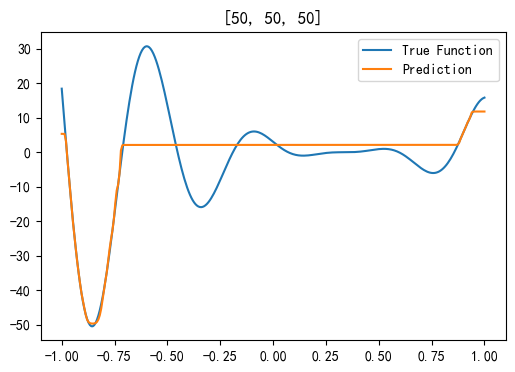

[1, 50, 50, 50, 50, 1]
torch.Size([50, 50])
Steps: 1000, loss: 5.293e+01
Steps: 2000, loss: 3.926e+00
Steps: 3000, loss: 1.922e-01
Steps: 4000, loss: 2.083e-02
Steps: 5000, loss: 1.698e-03
Steps: 6000, loss: 8.720e-04
Steps: 7000, loss: 4.451e-03
Steps: 8000, loss: 9.223e-03
Steps: 9000, loss: 3.032e-04
Steps: 10000, loss: 1.994e-01
structure: [50, 50, 50, 50] MSE: 0.5174054236729603 MAE: 0.2797003729563872


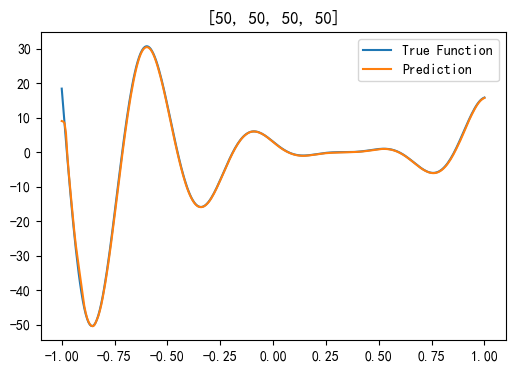

[1, 100, 100, 1]
torch.Size([1, 100])
Steps: 1000, loss: 3.871e+01
Steps: 2000, loss: 2.838e+01
Steps: 3000, loss: 2.430e+01
Steps: 4000, loss: 2.239e+01
Steps: 5000, loss: 2.188e+01
Steps: 6000, loss: 2.170e+01
Steps: 7000, loss: 2.164e+01
Steps: 8000, loss: 2.163e+01
Steps: 9000, loss: 2.162e+01
Steps: 10000, loss: 2.162e+01
structure: [100, 100] MSE: 17.44382386901866 MAE: 2.4901433858276354


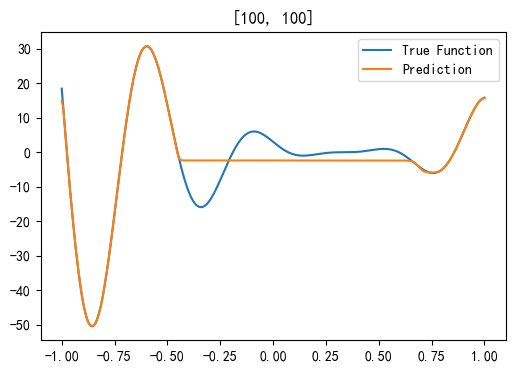

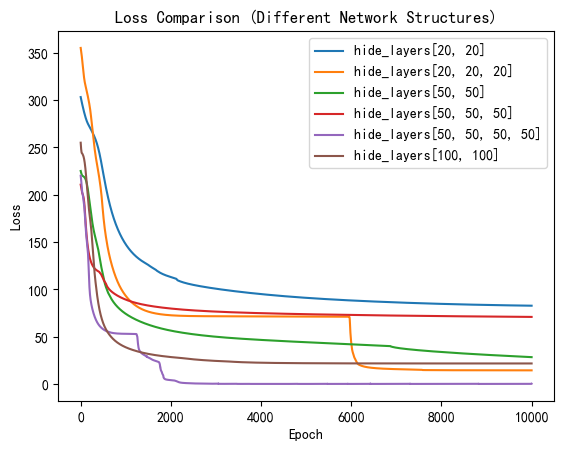

In [10]:
## ----网络结构影响----
hide_layers = [[20,20], [20,20,20], [50,50], [50,50,50],[50,50,50,50],[100,100]]
loss_dict_q2 = {}

for s in hide_layers:
    layers_q2 = [1] + s +[1]
    print(layers_q2)

    x_train_q2, y_train_q2, x_ref_q2, y_ref_q2 = generate_data()
    model_q2, loss_q2= train_model(x_train_q2, y_train_q2, layers=layers_q2)

    loss_dict_q2['hide_layers'+str(s)]=loss_q2
    x_test_q2, y_true_q2, y_pred_q2, mse_q2, mae_q2 = evaluate(model_q2)
    print('structure:', s, "MSE:", mse_q2, "MAE:", mae_q2)
    plot_result(x_test_q2, y_true_q2, y_pred_q2, str(s))

plot_loss(loss_dict_q2, title='Loss Comparison (Different Network Structures)')


## 问题3：激活函数影响

torch.Size([1, 50])
Steps: 1000, loss: 6.386e+01
Steps: 2000, loss: 3.975e+00
Steps: 3000, loss: 2.011e+00
Steps: 4000, loss: 1.875e+00
Steps: 5000, loss: 1.857e+00
Steps: 6000, loss: 1.861e+00
Steps: 7000, loss: 1.850e+00
Steps: 8000, loss: 1.848e+00
Steps: 9000, loss: 1.856e+00
Steps: 10000, loss: 1.848e+00
structure: [100, 100] MSE: 2.1214838448523565 MAE: 0.9757433366898101


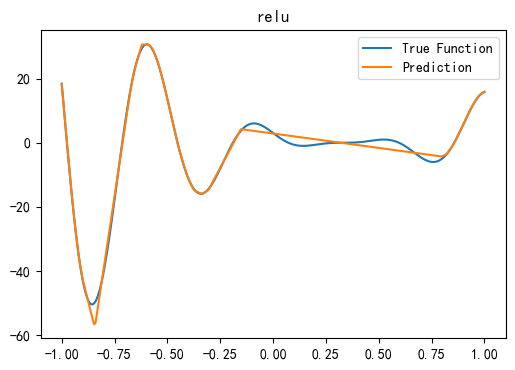

torch.Size([1, 50])
Steps: 1000, loss: 5.081e+01
Steps: 2000, loss: 2.372e+01
Steps: 3000, loss: 1.860e+01
Steps: 4000, loss: 1.689e+01
Steps: 5000, loss: 1.603e+01
Steps: 6000, loss: 1.542e+01
Steps: 7000, loss: 1.493e+01
Steps: 8000, loss: 1.453e+01
Steps: 9000, loss: 1.376e+01
Steps: 10000, loss: 1.323e+01
structure: [100, 100] MSE: 18.740146737163354 MAE: 2.3283824841541554


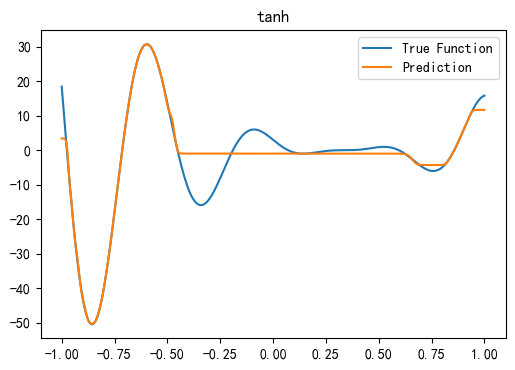

torch.Size([1, 50])
Steps: 1000, loss: 1.283e+02
Steps: 2000, loss: 6.907e+01
Steps: 3000, loss: 5.025e+01
Steps: 4000, loss: 3.803e+01
Steps: 5000, loss: 3.239e+01
Steps: 6000, loss: 3.012e+01
Steps: 7000, loss: 2.932e+01
Steps: 8000, loss: 2.906e+01
Steps: 9000, loss: 2.897e+01
Steps: 10000, loss: 2.894e+01
structure: [100, 100] MSE: 56.79314973124472 MAE: 2.8147226360049324


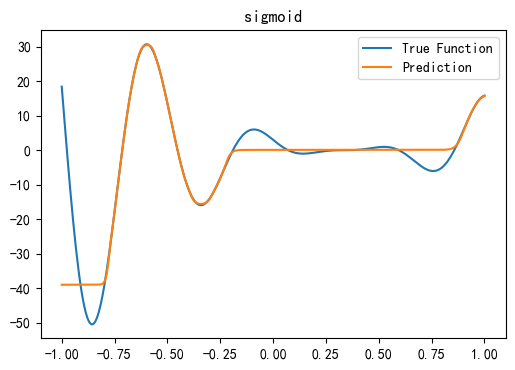

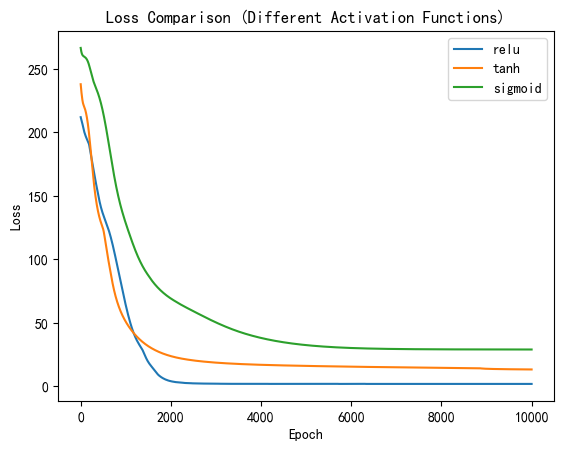

In [11]:
## ----激活函数影响----
activations = ['relu', 'tanh', 'sigmoid']
loss_dict_q3 = {}

for act in activations:
    x_train_q3, y_train_q3, x_ref_q3, y_ref_q3 = generate_data()
    model_q3, loss_q3= train_model(x_train_q3, y_train_q3, actn = act)

    loss_dict_q3[act]=loss_q3
    x_test_q3, y_true_q3, y_pred_q3, mse_q3, mae_q3 = evaluate(model_q3)
    print('structure:', s, "MSE:", mse_q3, "MAE:", mae_q3)
    plot_result(x_test_q3, y_true_q3, y_pred_q3, act)


plot_loss(loss_dict_q3, title='Loss Comparison (Different Activation Functions)')